In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
# Ruta del directorio donde está el script
SCRIPT_DIR = os.getcwd()  # Directorio actual desde donde se ejecuta la celda

# Nombres de archivo en esa carpeta
sleep_file = os.path.join(SCRIPT_DIR, "simulated_sleep_data.csv")
fc_file = os.path.join(SCRIPT_DIR, "simulated_heart_rate_data.csv")
user_file = os.path.join(SCRIPT_DIR, "simulated_user_data.csv")

In [3]:
# Semilla para reproducibilidad
np.random.seed(42)
random.seed(42)

In [4]:
# Constantes
NUM_USERS = 100
MIN_DAYS = 1
MAX_DAYS = 300
MIN_SLEEP_SECS = 14400  # 4 horas
MAX_SLEEP_SECS = 36000  # 10 horas
DEVICES = ['Source_A', 'Source_B', 'Source_C', 'Source_D', 'Source_E', 'Source_F']
ACTIVITIES = ['Cycling', 'Walking', 'Running', 'Swimming', 'Yoga', 'Gym']
YEAR = 2024

In [5]:
# Generar datos de sueño simulados
def generate_sleep_stages(total_sleep_seconds):
    deep = int(total_sleep_seconds * np.random.uniform(0.13, 0.23))
    rem = int(total_sleep_seconds * np.random.uniform(0.20, 0.25))
    light = int(total_sleep_seconds * np.random.uniform(0.45, 0.55))
    awake = int(total_sleep_seconds * np.random.uniform(0.03, 0.07))
    fall_asleep = total_sleep_seconds - (deep + rem + light + awake)
    return max(0, light), max(0, rem), max(0, deep), max(0, fall_asleep), max(0, awake)

sleep_records = []
for user_id in range(1, NUM_USERS + 1):
    num_nights = np.random.randint(MIN_DAYS, MAX_DAYS + 1)
    base_date = datetime(YEAR, 1, 1)
    for i in range(num_nights):
        date = base_date + timedelta(days=i)
        sleep_start = datetime(date.year, date.month, date.day,
                               np.random.randint(21, 24), np.random.randint(0, 60))
        total_sleep = np.random.randint(MIN_SLEEP_SECS, MAX_SLEEP_SECS + 1)
        light, rem, deep, fall_asleep, awake = generate_sleep_stages(total_sleep)
        device = random.choice(DEVICES)
        is_anomalous = random.random() < 0.15  # 15% anomalías

        if is_anomalous:
            light = rem = deep = fall_asleep = awake = np.nan

        sleep_records.append({
            "user_id": user_id,
            "sleep_id": f"{user_id}_{date.strftime('%Y%m%d')}",
            "timestamp": sleep_start.isoformat(),
            "light": light,
            "rem": rem,
            "deep": deep,
            "fall_asleep": fall_asleep,
            "awake": awake,
            "device": device,
            "is_anomalous": is_anomalous
        })

# Duplicados (10%)
num_duplicates = int(len(sleep_records) * 0.1)
duplicate_sleep_records = random.sample(sleep_records, num_duplicates)
for record in duplicate_sleep_records:
    dup = record.copy()
    dup["device"] = random.choice(DEVICES)
    for stage in ["light", "rem", "deep", "fall_asleep", "awake"]:
        if pd.notnull(dup[stage]):
            dup[stage] += np.random.randint(-60, 60)
    sleep_records.append(dup)


In [6]:
df_sleep = pd.DataFrame(sleep_records)
df_sleep

,user_id,sleep_id,timestamp,light,rem,deep,fall_asleep,awake,device,is_anomalous
0,1,1_20240101,2024-01-01T21:14:00,NaN,NaN,NaN,NaN,NaN,Source_F,True
1,1,1_20240102,2024-01-02T21:35:00,15886.0,6170.0,5935.0,378.0,2054.0,Source_F,False
2,1,1_20240103,2024-01-03T22:59:00,NaN,NaN,NaN,NaN,NaN,Source_B,True
3,1,1_20240104,2024-01-04T23:58:00,16225.0,7155.0,4799.0,3555.0,1608.0,Source_A,False
4,1,1_20240105,2024-01-05T23:50:00,NaN,NaN,NaN,NaN,NaN,Source_E,True
...,...,...,...,...,...,...,...,...,...,...
15864,56,56_20240221,2024-02-21T22:29:00,10785.0,4863.0,4760.0,2374.0,1070.0,Source_B,False
15865,44,44_20240202,2024-02-02T22:16:00,NaN,NaN,NaN,NaN,NaN,Source_F,True
15866,87,87_20240104,2024-01-04T22:09:00,13147.0,5327.0,5357.0,30.0,1384.0,Source_D,False
15867,52,52_20240209,2024-02-09T21:03:00,18127.0,6971.0,5909.0,1241.0,1042.0,Source_B,False


In [7]:
# Frecuencia cardíaca
fc_records = []
for record in sleep_records:
    user_id = record["user_id"]
    sleep_timestamp = datetime.fromisoformat(record["timestamp"])
    num_events = np.random.randint(1, 11)
    for _ in range(num_events):
        event_time = sleep_timestamp - timedelta(hours=np.random.randint(6, 24),
                                                 minutes=np.random.randint(0, 60))
        duration = np.random.randint(300, 7200)
        activity = random.choice(ACTIVITIES)
        profile = np.random.choice(['sedentary', 'active'])

        if profile == 'sedentary':
            hr_min = np.random.randint(60, 71)
            hr_avg = np.random.randint(70, 91)
            hr_max = np.random.randint(90, 131)
        else:
            hr_min = np.random.randint(40, 56)
            hr_avg = np.random.randint(55, 76)
            hr_max = np.random.randint(75, 191)

        is_anomalous = False
        if random.random() < 0.15:
            is_anomalous = True
            hr_min = np.random.randint(20, 35)
            hr_avg = np.random.randint(35, 45)
            hr_max = np.random.randint(200, 220)

        fc_records.append({
            "user_id": user_id,
            "sleep_id": record["sleep_id"],
            "timestamp": event_time.isoformat(),
            "duration_secs": duration,
            "activity": activity,
            "hr_min": hr_min,
            "hr_avg": hr_avg,
            "hr_max": hr_max,
            "device": random.choice(DEVICES),
            "is_anomalous": is_anomalous
        })

# Duplicados FC
num_fc_duplicates = int(len(fc_records) * 0.1)
duplicate_fc_records = random.sample(fc_records, num_fc_duplicates)
for rec in duplicate_fc_records:
    dup = rec.copy()
    dup["device"] = random.choice(DEVICES)
    dup["hr_avg"] += np.random.randint(-3, 4)
    fc_records.append(dup)

In [8]:
df_fc = pd.DataFrame(fc_records)
df_fc

,user_id,sleep_id,timestamp,duration_secs,activity,hr_min,hr_avg,hr_max,device,is_anomalous
0,1,1_20240101,2024-01-01T03:04:00,5236,Swimming,66,76,116,Source_C,False
1,1,1_20240101,2024-01-01T05:10:00,6038,Gym,70,89,90,Source_A,False
2,1,1_20240101,2024-01-01T07:21:00,6348,Walking,69,71,122,Source_E,False
3,1,1_20240101,2024-01-01T11:40:00,1874,Swimming,67,72,123,Source_E,False
4,1,1_20240101,2024-01-01T06:55:00,7037,Cycling,23,41,215,Source_B,True
...,...,...,...,...,...,...,...,...,...,...
96359,41,41_20240125,2024-01-25T00:47:00,601,Gym,67,82,114,Source_D,False
96360,57,57_20240109,2024-01-09T14:09:00,1742,Running,32,36,213,Source_F,True
96361,5,5_20240411,2024-04-11T16:25:00,6067,Cycling,55,68,159,Source_A,False
96362,27,27_20240629,2024-06-29T03:35:00,7044,Walking,46,66,172,Source_B,False


In [9]:
# Verifica si los archivos ya existen
for filepath in [sleep_file, fc_file]:
    if os.path.exists(filepath):
        print(f"Sobrescribiendo archivo: {os.path.basename(filepath)}")

# Guardar como CSV
df_sleep.to_csv(sleep_file, index=False)
df_fc.to_csv(fc_file, index=False)

print("Dataset files generated successfully.")

Sobrescribiendo archivo: simulated_sleep_data.csv
Sobrescribiendo archivo: simulated_heart_rate_data.csv
Dataset files generated successfully.


In [10]:
def generate_user_demographics(user_ids):

    demographics = []

    for uid in user_ids:
        age = np.random.randint(18, 70)  # Adultos jóvenes a mayores
        gender = random.choice(['Male', 'Female', 'Other'])
        
        # Estatura y peso según sexo
        if gender == 'Male':
            height = np.random.normal(175, 7)
            weight = np.random.normal(78, 10)
        elif gender == 'Female':
            height = np.random.normal(162, 6)
            weight = np.random.normal(65, 8)
        else:
            height = np.random.normal(168, 8)
            weight = np.random.normal(72, 9)

        height = round(height, 1)
        weight = round(weight, 1)

        # Calcular BMI
        height_m = height / 100
        bmi = round(weight / (height_m ** 2), 1)

        # Nivel de actividad física
        activity_level = random.choices(
            ['Sedentary', 'Light', 'Moderate', 'Active', 'Athlete'],
            weights=[0.2, 0.3, 0.3, 0.15, 0.05]
        )[0]

        registration_timestamp = datetime.now().isoformat() # Ajustar formato y poner una fecha anterior a los registros simulados

        # Dispositivo principal
        #primary_device = random.choice(['Source_A', 'Source_B', 'Source_C', 'Source_D', 'Source_E', 'Source_F'])

        demographics.append({
            'user_id': uid,
            'registered_at': registration_timestamp,
            'age': age,
            'gender': gender,
            'height_cm': height,
            'weight_kg': weight,
            'bmi': bmi,
            'activity_level': activity_level
        })

    return pd.DataFrame(demographics)

In [11]:
# Obtener user_ids únicos
user_ids = df_sleep['user_id'].unique()

# Generar datos demográficos con BMI
df_users = generate_user_demographics(user_ids)

# Vista rápida
df_users

,user_id,registered_at,age,gender,height_cm,weight_kg,bmi,activity_level
0,1,2025-07-03T11:51:06.546781,69,Male,180.8,84.3,25.8,Active
1,2,2025-07-03T11:51:06.546814,22,Female,171.4,67.3,22.9,Athlete
2,3,2025-07-03T11:51:06.546832,33,Female,167.6,72.6,25.8,Sedentary
3,4,2025-07-03T11:51:06.546849,61,Male,175.1,66.6,21.7,Moderate
4,5,2025-07-03T11:51:06.546864,58,Female,155.2,63.8,26.5,Moderate
...,...,...,...,...,...,...,...,...
95,96,2025-07-03T11:51:06.547956,26,Female,168.8,55.9,19.6,Light
96,97,2025-07-03T11:51:06.547967,51,Other,168.8,67.9,23.8,Moderate
97,98,2025-07-03T11:51:06.547978,29,Male,162.8,96.0,36.2,Active
98,99,2025-07-03T11:51:06.547989,58,Female,159.3,67.9,26.8,Sedentary


In [12]:
# Guardar como CSV
df_users.to_csv(user_file, index=False)

print("Dataset files generated successfully.")

Dataset files generated successfully.


In [14]:
# Data Visualization Function
def plot_user_timeseries(user_id, df_sleep, df_fc, start_date=None, end_date=None):
    """
    Visualiza las series de tiempo combinadas de sueño y frecuencia cardíaca para un usuario.

    Parámetros:
        user_id (int): ID del usuario.
        df_sleep (pd.DataFrame): DataFrame de sueño.
        df_fc (pd.DataFrame): DataFrame de frecuencia cardíaca.
        start_date (str): Fecha de inicio en formato 'YYYY-MM-DD'. Opcional.
        end_date (str): Fecha de fin en formato 'YYYY-MM-DD'. Opcional.
    """

    # Filtrar datos por usuario
    sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
    fc_user = df_fc[df_fc['user_id'] == user_id].copy()

    # Convertir timestamps a datetime
    sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
    fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])

    # Filtrar por rango de fechas si se especifica
    if start_date:
        start = pd.to_datetime(start_date)
        sleep_user = sleep_user[sleep_user['timestamp'] >= start]
        fc_user = fc_user[fc_user['timestamp'] >= start]
    if end_date:
        end = pd.to_datetime(end_date)
        sleep_user = sleep_user[sleep_user['timestamp'] <= end]
        fc_user = fc_user[fc_user['timestamp'] <= end]

    # Calcular duración total del sueño
    sleep_user['sleep_total'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1)

    # Crear figura
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Gráfico de sueño
    ax1.plot(sleep_user['timestamp'], sleep_user['sleep_total'] / 3600,
             label='Total Sleep (hrs)', color='blue', marker='o', linewidth=2)
    ax1.set_ylabel('Sleep Duration (hrs)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Anomalías de sueño
    anomalous_sleep = sleep_user[sleep_user['is_anomalous']]
    if not anomalous_sleep.empty:
        ax1.scatter(anomalous_sleep['timestamp'], [0.2]*len(anomalous_sleep),
                    color='red', label='Anomalous Sleep', zorder=5)

    # Segundo eje: frecuencia cardíaca
    ax2 = ax1.twinx()
    ax2.set_ylabel('Heart Rate (bpm)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    ax2.plot(fc_user['timestamp'], fc_user['hr_min'], label='HR Min', color='green', linestyle='dotted')
    ax2.plot(fc_user['timestamp'], fc_user['hr_avg'], label='HR Avg', color='orange', linestyle='-')
    ax2.plot(fc_user['timestamp'], fc_user['hr_max'], label='HR Max', color='red', linestyle='dashed')

    # Anomalías de FC
    anomalous_fc = fc_user[fc_user['is_anomalous']]
    if not anomalous_fc.empty:
        ax2.scatter(anomalous_fc['timestamp'], anomalous_fc['hr_max'],
                    color='darkred', marker='x', label='Anomalous HR')

    # Ejes temporales y diseño
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    fig.autofmt_xdate()
    plt.title(f"Sleep & Heart Rate Time Series - User {user_id}")
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

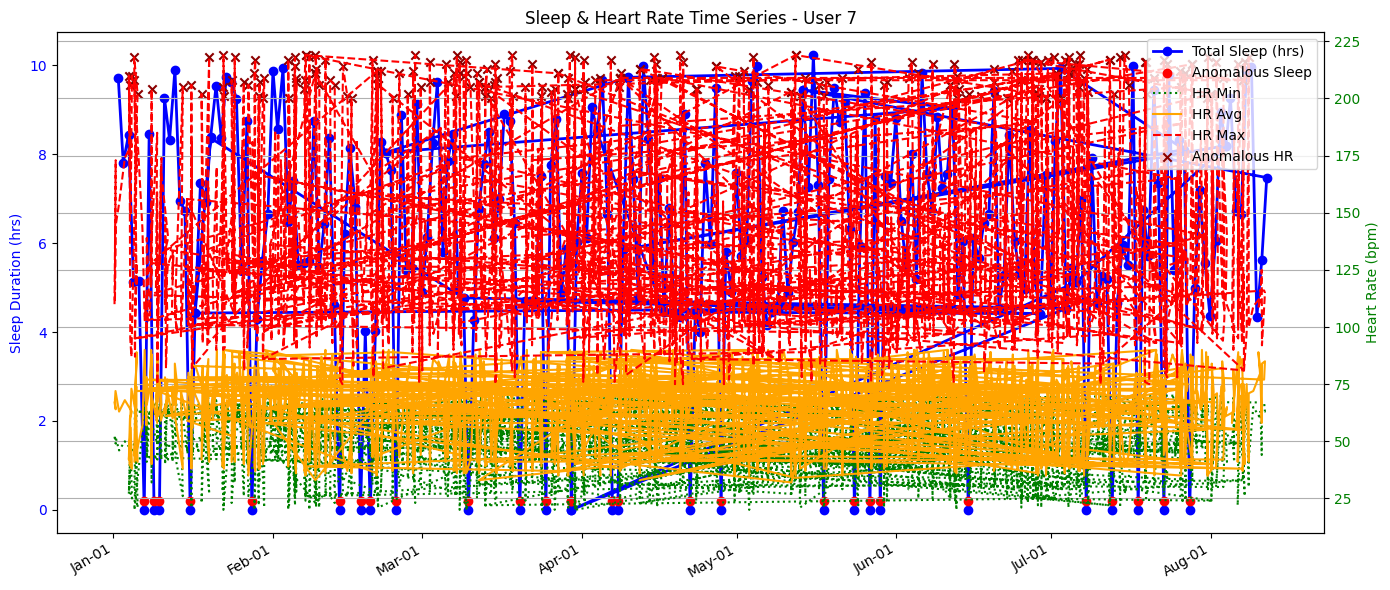

In [17]:
# Rango completo
plot_user_timeseries(user_id=7, df_sleep=df_sleep, df_fc=df_fc)

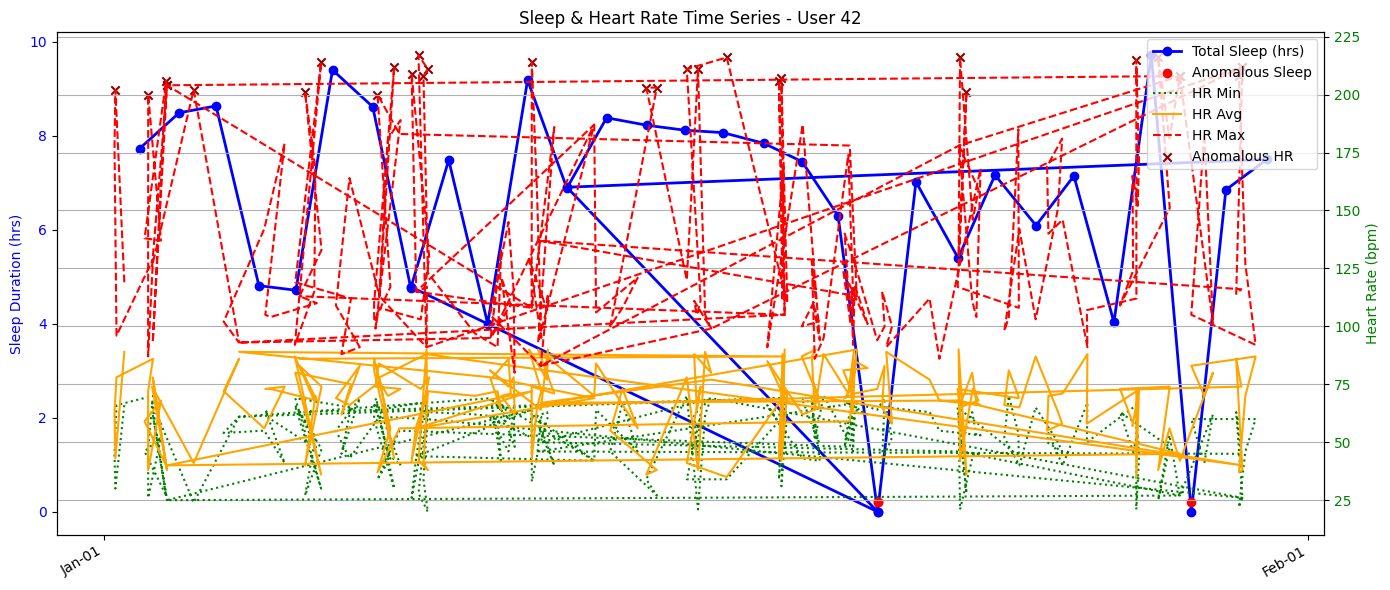

In [25]:
# Solo enero
plot_user_timeseries(user_id=42, df_sleep=df_sleep, df_fc=df_fc,
                     start_date='2024-01-01', end_date='2024-01-31')

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

def plot_user_sleep_hours(user_id, df_sleep, start_date=None, end_date=None):
    """
    Grafica las horas totales de sueño por día para un usuario específico.

    Parámetros:
        user_id (int): ID del usuario a graficar.
        df_sleep (pd.DataFrame): DataFrame con los datos de sueño.
        start_date (str): Fecha de inicio en formato 'YYYY-MM-DD'. Opcional.
        end_date (str): Fecha de fin en formato 'YYYY-MM-DD'. Opcional.
    """
    # Filtrar usuario
    user_data = df_sleep[df_sleep['user_id'] == user_id].copy()

    # Convertir timestamps
    user_data['timestamp'] = pd.to_datetime(user_data['timestamp'])

    # Calcular horas totales de sueño
    user_data['sleep_total_hrs'] = user_data[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

    # Filtrar por fechas si se especifica
    if start_date:
        user_data = user_data[user_data['timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        user_data = user_data[user_data['timestamp'] <= pd.to_datetime(end_date)]

    # Ordenar por fecha
    user_data.sort_values(by='timestamp', inplace=True)

    # Graficar
    plt.figure(figsize=(12, 5))
    plt.plot(user_data['timestamp'], user_data['sleep_total_hrs'], marker='o',
             linestyle='-', color='midnightblue', label='Total Sleep (hrs)')

    # Marcar anomalías
    anomalies = user_data[user_data['is_anomalous']]
    if not anomalies.empty:
        plt.scatter(anomalies['timestamp'], [0]*len(anomalies), color='red',
                    label='Anomalous (missing data)', marker='x')

    # Ejes y diseño
    plt.title(f"Total Sleep Duration by Night - User {user_id}")
    plt.xlabel("Date")
    plt.ylabel("Sleep Duration (hours)")
    plt.grid(True)
    plt.ylim(0, 12)
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.tight_layout()
    plt.legend()
    plt.show()

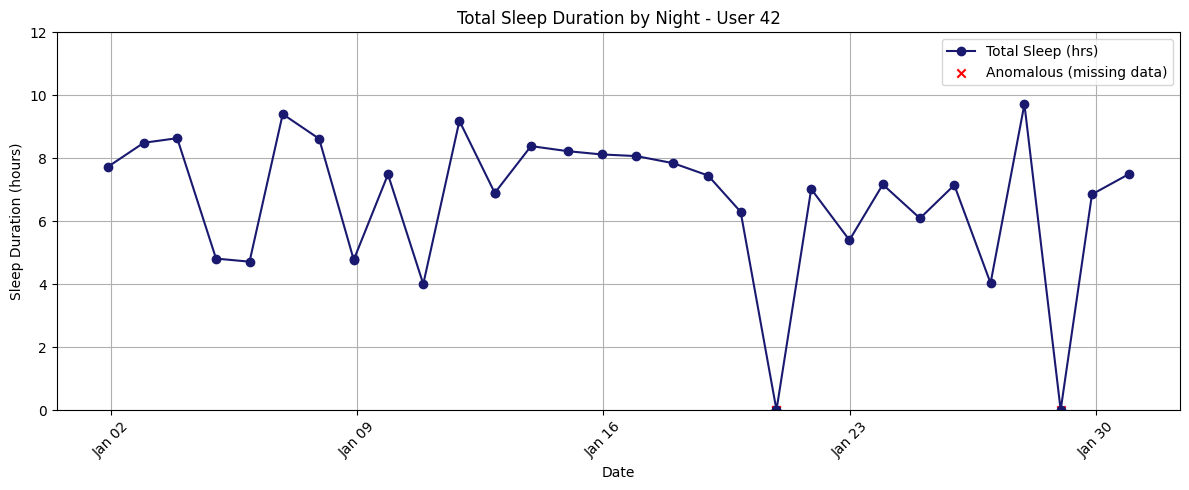

In [19]:
# Solo enero de 2024
plot_user_sleep_hours(user_id=42, df_sleep=df_sleep,
                      start_date='2024-01-01', end_date='2024-01-31')

In [20]:
def plot_user_sleep_stages(user_id, df_sleep, start_date=None, end_date=None):
    """
    Visualiza las etapas de sueño y la duración total para un usuario en un periodo.

    Parámetros:
        user_id (int): ID del usuario a graficar.
        df_sleep (pd.DataFrame): DataFrame con los datos de sueño.
        start_date (str): Fecha de inicio en formato 'YYYY-MM-DD'. Opcional.
        end_date (str): Fecha de fin en formato 'YYYY-MM-DD'. Opcional.
    """
    # Filtrar por usuario
    user_data = df_sleep[df_sleep['user_id'] == user_id].copy()
    user_data['timestamp'] = pd.to_datetime(user_data['timestamp'])

    # Filtrar por fechas si se especifican
    if start_date:
        user_data = user_data[user_data['timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        user_data = user_data[user_data['timestamp'] <= pd.to_datetime(end_date)]

    # Ordenar por fecha
    user_data.sort_values(by='timestamp', inplace=True)

    # Convertir cada etapa a horas
    for col in ['light', 'rem', 'deep', 'fall_asleep', 'awake']:
        user_data[col + '_hrs'] = user_data[col] / 3600

    # Calcular total
    user_data['total_sleep_hrs'] = user_data[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

    # Crear gráfico de barras apiladas
    plt.figure(figsize=(14, 6))
    bottom = np.zeros(len(user_data))

    # Colores para cada etapa
    stages = {
        'fall_asleep_hrs': 'lightgray',
        'awake_hrs': 'crimson',
        'light_hrs': 'cornflowerblue',
        'rem_hrs': 'mediumseagreen',
        'deep_hrs': 'darkblue'
    }

    for stage, color in stages.items():
        plt.bar(user_data['timestamp'], user_data[stage], bottom=bottom, label=stage.replace('_hrs', '').capitalize(), color=color)
        bottom += user_data[stage].fillna(0)

    # Superponer línea con duración total
    plt.plot(user_data['timestamp'], user_data['total_sleep_hrs'], color='black', linewidth=2, label='Total Sleep', linestyle='--', marker='o')

    # Formato de ejes
    plt.xlabel("Date")
    plt.ylabel("Sleep Duration (hrs)")
    plt.title(f"Sleep Stage Composition per Night - User {user_id}")
    plt.xticks(rotation=45)
    plt.ylim(0, 12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.legend()
    plt.tight_layout()
    plt.show()

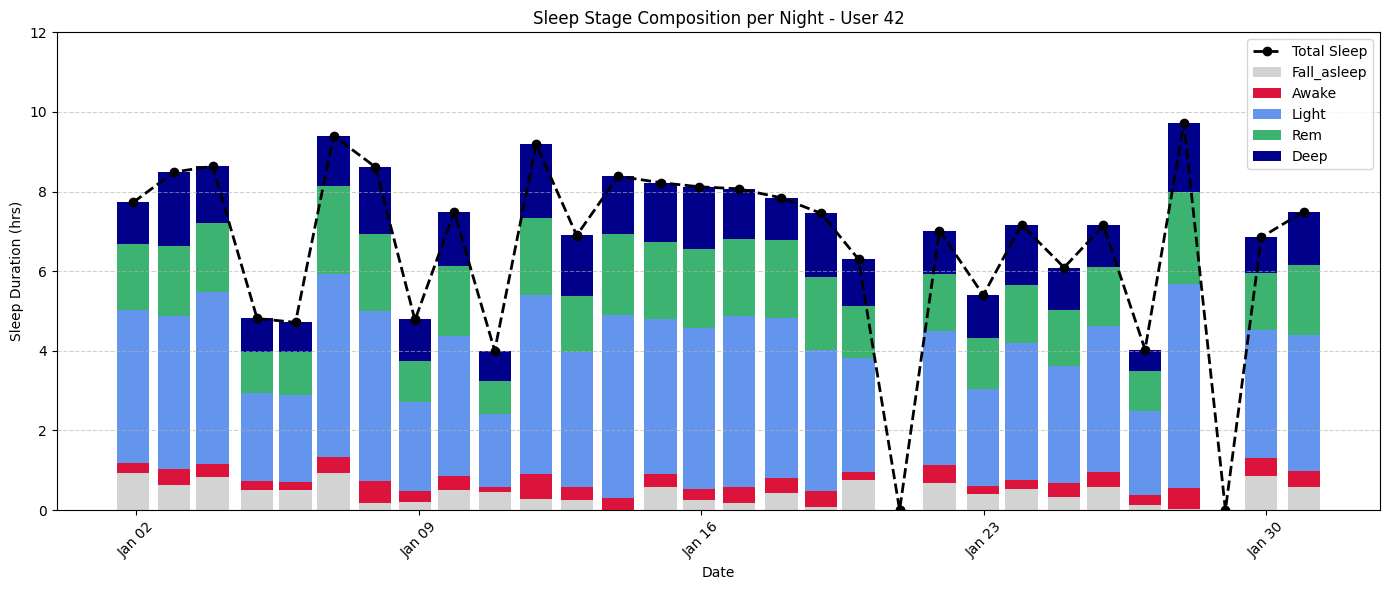

In [21]:
# Filtrar por enero
plot_user_sleep_stages(user_id=42, df_sleep=df_sleep,
                       start_date='2024-01-01', end_date='2024-01-31')

In [22]:
def plot_user_heart_rate_events(user_id, df_fc, start_date=None, end_date=None):
    """
    Visualiza los componentes de frecuencia cardíaca por evento para un usuario.

    Parámetros:
        user_id (int): ID del usuario.
        df_fc (pd.DataFrame): DataFrame con datos de frecuencia cardíaca.
        start_date (str): Fecha inicial (opcional, formato 'YYYY-MM-DD').
        end_date (str): Fecha final (opcional, formato 'YYYY-MM-DD').
    """
    # Filtrar usuario
    user_data = df_fc[df_fc['user_id'] == user_id].copy()
    user_data['timestamp'] = pd.to_datetime(user_data['timestamp'])

    # Filtrar por fechas si se especifican
    if start_date:
        user_data = user_data[user_data['timestamp'] >= pd.to_datetime(start_date)]
    if end_date:
        user_data = user_data[user_data['timestamp'] <= pd.to_datetime(end_date)]

    # Ordenar eventos por fecha
    user_data.sort_values(by='timestamp', inplace=True)

    # Crear figura
    plt.figure(figsize=(14, 5))

    # Trazar cada componente de FC
    plt.plot(user_data['timestamp'], user_data['hr_min'], label='HR Min', color='green', linestyle='dotted', marker='o')
    plt.plot(user_data['timestamp'], user_data['hr_avg'], label='HR Avg', color='orange', linestyle='solid', marker='o')
    plt.plot(user_data['timestamp'], user_data['hr_max'], label='HR Max', color='red', linestyle='dashed', marker='o')

    # Formato de ejes
    plt.xlabel("Date")
    plt.ylabel("Heart Rate (bpm)")
    plt.title(f"Heart Rate Events - User {user_id}")
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.ylim(30, 230)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.legend()
    plt.tight_layout()
    plt.show()

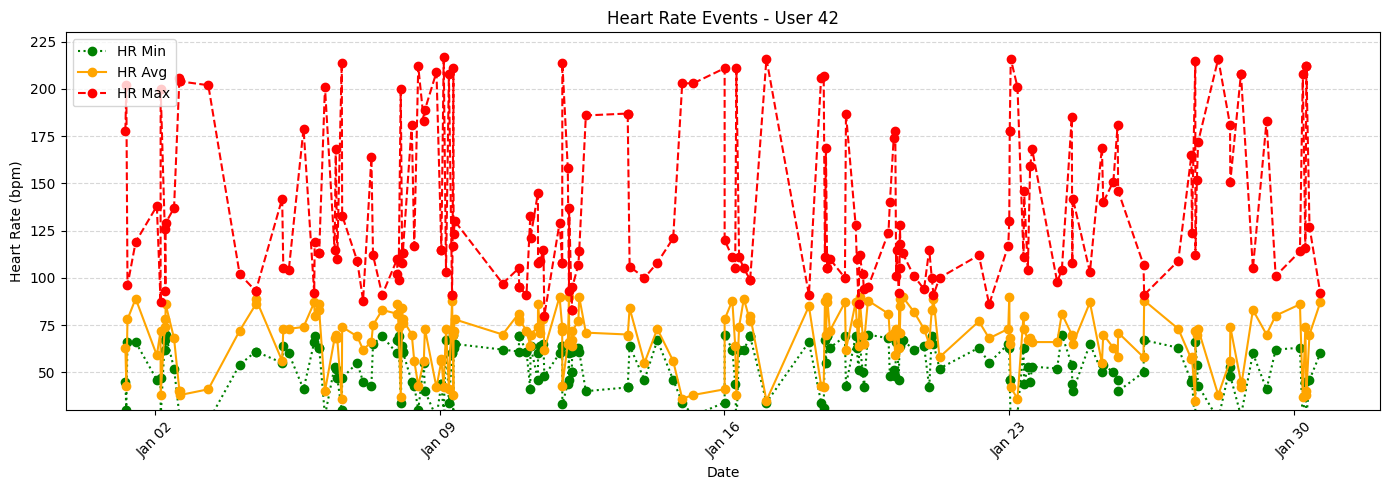

In [24]:
# Eventos del mes de febrero
plot_user_heart_rate_events(user_id=42, df_fc=df_fc,
                            start_date='2024-01-01', end_date='2024-01-31')

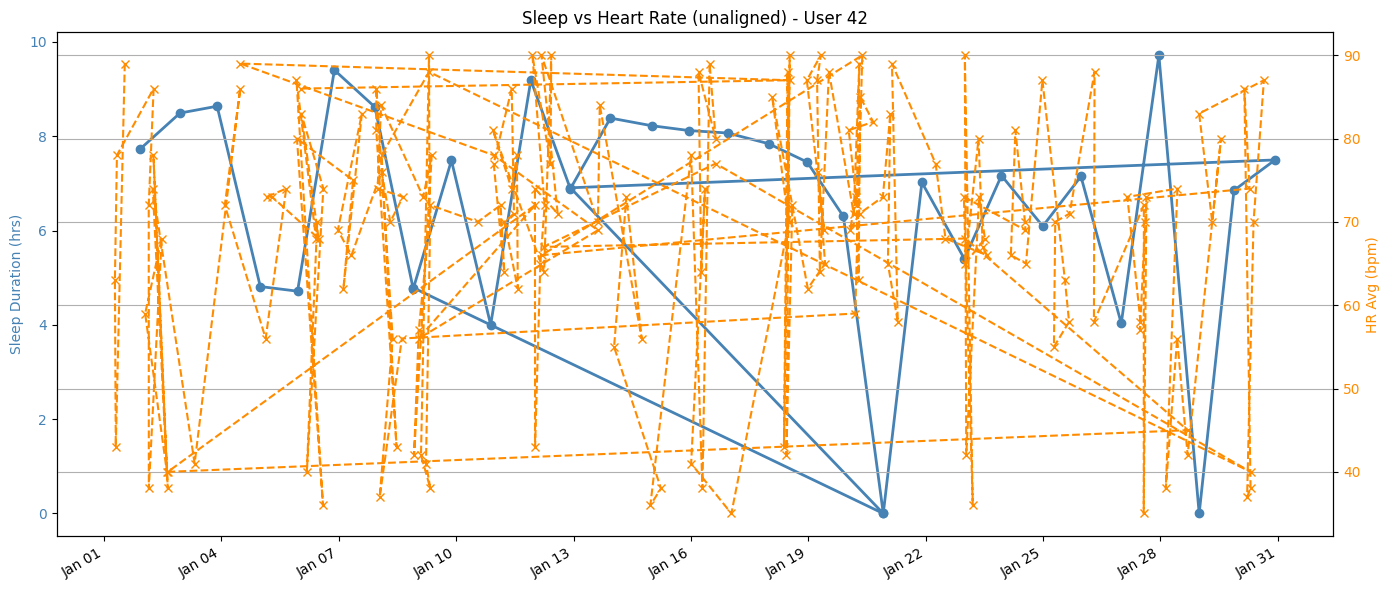

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Asumiendo que tienes ya df_sleep y df_fc en memoria
user_id = 42  # Cambia por el ID deseado
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()

# Asegúrate de que los timestamps estén en formato datetime
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])

# Selecciona un rango de 30 días desde el primer día de sueño
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)

# Filtra los datos al mes
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]

# Calcula duración total del sueño por noche
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

# Crear visualización
fig, ax1 = plt.subplots(figsize=(14, 6))

# Serie de sueño
ax1.plot(sleep_user['timestamp'], sleep_user['sleep_total_hrs'],
         label='Total Sleep (hrs)', color='steelblue', marker='o', linewidth=2)
ax1.set_ylabel('Sleep Duration (hrs)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Serie de FC promedio
ax2 = ax1.twinx()
ax2.plot(fc_user['timestamp'], fc_user['hr_avg'],
         label='HR Avg', color='darkorange', marker='x', linestyle='--')
ax2.set_ylabel('HR Avg (bpm)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Formato de fechas
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.title(f"Sleep vs Heart Rate (unaligned) - User {user_id}")
fig.autofmt_xdate()
plt.grid(True)
plt.tight_layout()
plt.show()

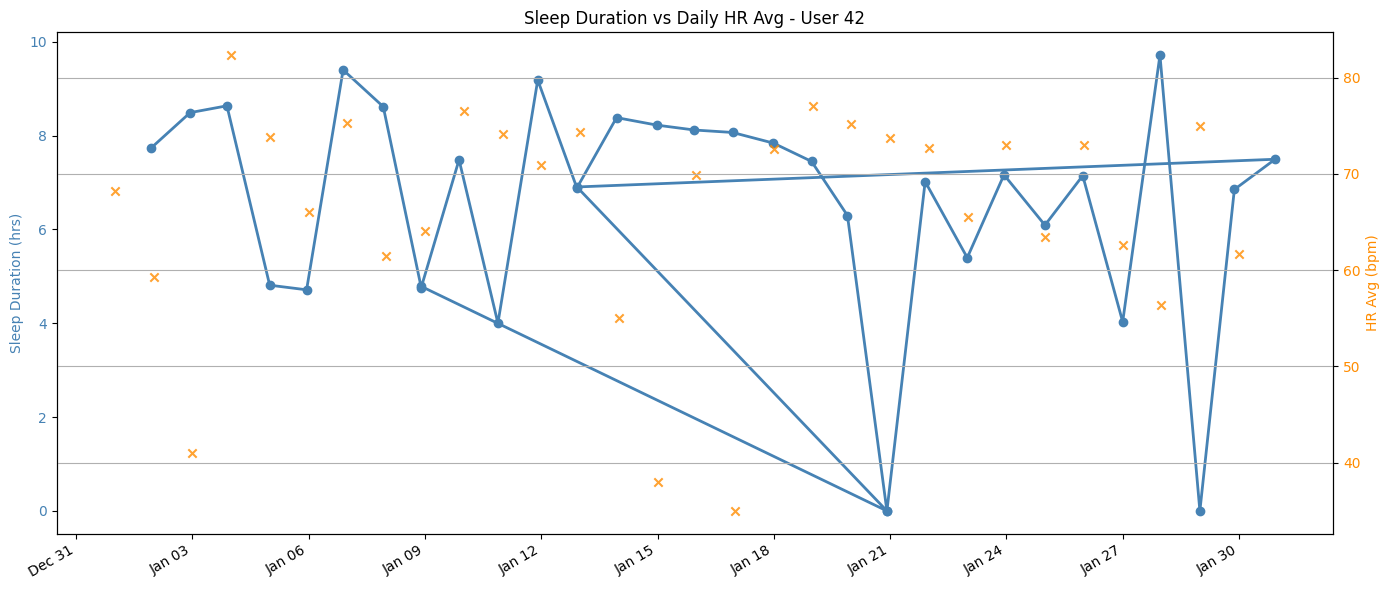

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Asumiendo que ya cargaste df_sleep y df_fc
user_id = 42  # o el que hayas elegido

# Filtrar datos
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()

# Asegurar tipo datetime
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])

# Seleccionar 1 mes de datos
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]

# Calcular duración total del sueño
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

# Calcular HR promedio diario
fc_user['date'] = fc_user['timestamp'].dt.floor('D')
fc_daily = fc_user.groupby('date')['hr_avg'].mean().reset_index()
fc_daily.rename(columns={'date': 'timestamp', 'hr_avg': 'hr_avg_daily'}, inplace=True)

# Graficar
fig, ax1 = plt.subplots(figsize=(14, 6))

# Línea de sueño
ax1.plot(sleep_user['timestamp'], sleep_user['sleep_total_hrs'],
         label='Total Sleep (hrs)', color='steelblue', marker='o', linewidth=2)
ax1.set_ylabel('Sleep Duration (hrs)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Puntos de FC promedio
ax2 = ax1.twinx()
ax2.scatter(fc_daily['timestamp'], fc_daily['hr_avg_daily'],
            label='Daily HR Avg', color='darkorange', alpha=0.8, marker='x')
ax2.set_ylabel('HR Avg (bpm)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Formato de fechas
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.title(f"Sleep Duration vs Daily HR Avg - User {user_id}")
fig.autofmt_xdate()
plt.grid(True)
plt.tight_layout()
plt.show()

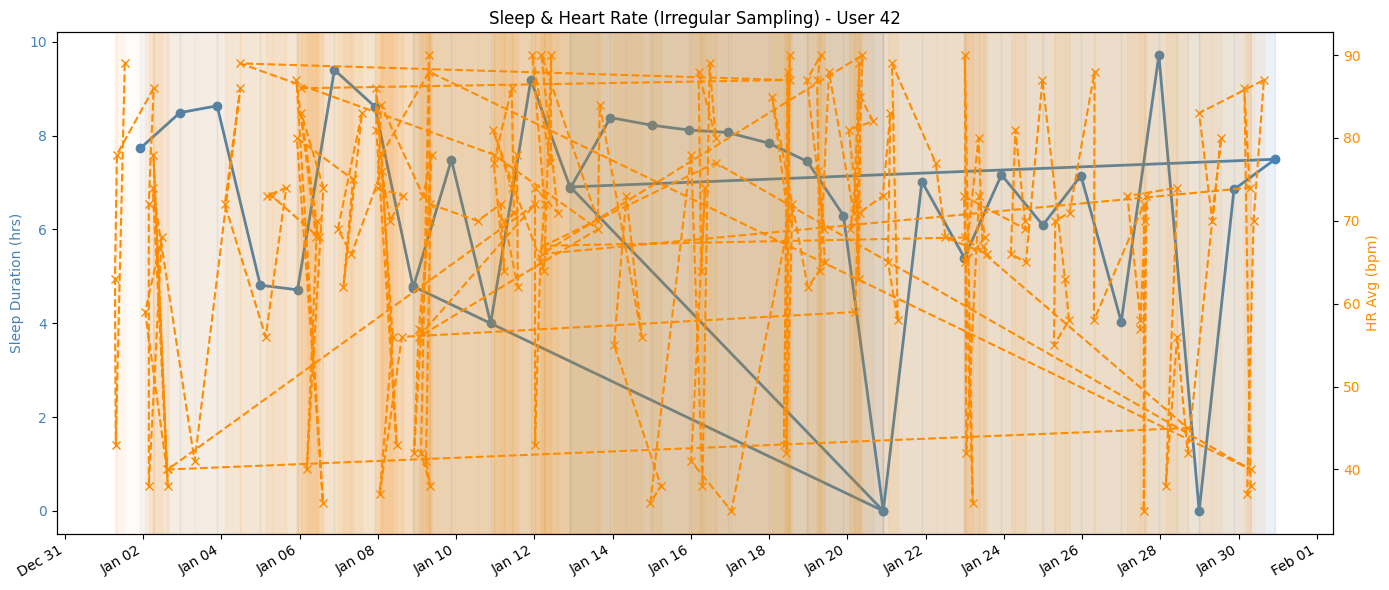

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# --- Extrae los datos del usuario ---
user_id = 42  # Cambia por el usuario que quieras analizar
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()

sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])

# Selecciona un rango de 30 días desde el primer registro de sueño
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]

# Calcula duración total del sueño por noche
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

# --- Visualización: muestra los gaps entre puntos ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# Serie de sueño
ax1.plot(sleep_user['timestamp'], sleep_user['sleep_total_hrs'],
         label='Total Sleep (hrs)', color='steelblue', marker='o', linewidth=2)
ax1.set_ylabel('Sleep Duration (hrs)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Dibuja líneas verticales entre puntos para resaltar los gaps de muestreo
for i in range(1, len(sleep_user)):
    prev = sleep_user['timestamp'].iloc[i-1]
    curr = sleep_user['timestamp'].iloc[i]
    ax1.axvspan(prev, curr, color='steelblue', alpha=0.05)

# Serie de FC promedio (segundo eje)
ax2 = ax1.twinx()
ax2.plot(fc_user['timestamp'], fc_user['hr_avg'],
         label='HR Avg', color='darkorange', marker='x', linestyle='--')
ax2.set_ylabel('HR Avg (bpm)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Dibuja líneas verticales entre eventos de FC para mostrar irregularidad
for i in range(1, len(fc_user)):
    prev = fc_user['timestamp'].iloc[i-1]
    curr = fc_user['timestamp'].iloc[i]
    ax2.axvspan(prev, curr, color='darkorange', alpha=0.03)

# Formato de fechas
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.title(f"Sleep & Heart Rate (Irregular Sampling) - User {user_id}")
fig.autofmt_xdate()
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


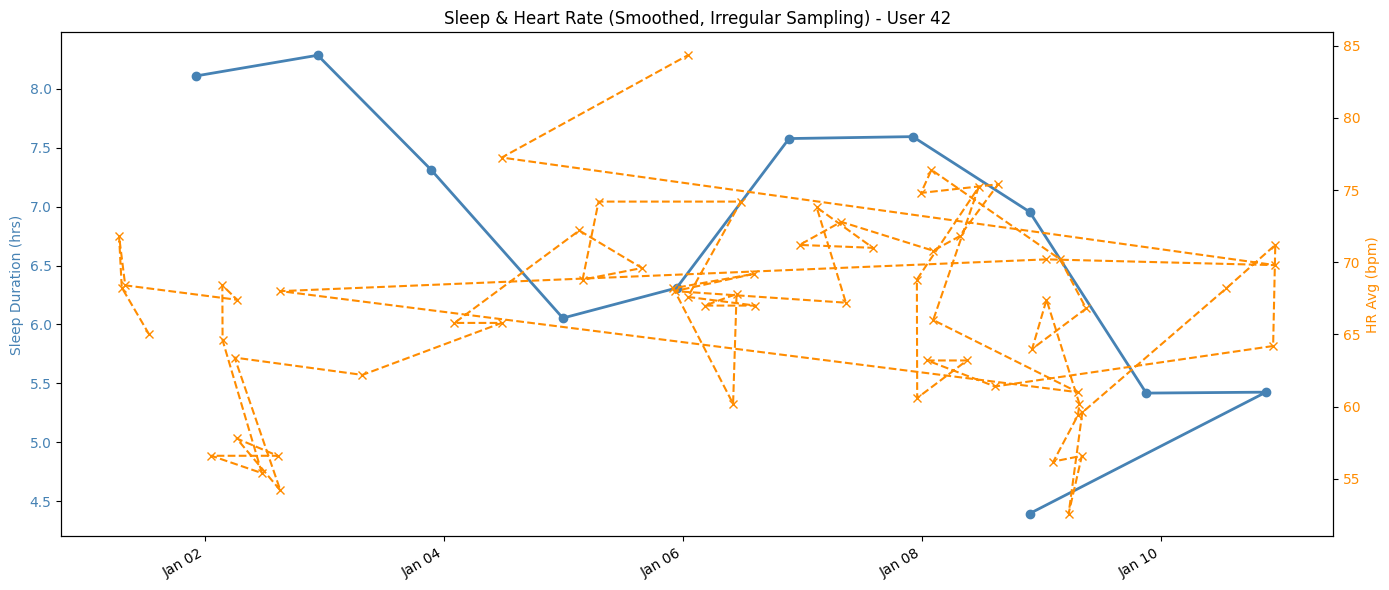

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# --- Prepara los datos ---
user_id = 42
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=10)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

# --- Suavizado con media móvil (window=3) ---
sleep_user['sleep_total_hrs_smooth'] = sleep_user['sleep_total_hrs'].rolling(window=3, min_periods=1, center=True).mean()
fc_user['hr_avg_smooth'] = fc_user['hr_avg'].rolling(window=5, min_periods=1, center=True).mean()

# --- Visualización suave ---
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(sleep_user['timestamp'], sleep_user['sleep_total_hrs_smooth'],
         label='Total Sleep (hrs, suavizado)', color='steelblue', marker='o', linewidth=2)
ax1.set_ylabel('Sleep Duration (hrs)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(fc_user['timestamp'], fc_user['hr_avg_smooth'],
         label='HR Avg (suavizado)', color='darkorange', marker='x', linestyle='--')
ax2.set_ylabel('HR Avg (bpm)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.title(f"Sleep & Heart Rate (Smoothed, Irregular Sampling) - User {user_id}")
fig.autofmt_xdate()
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


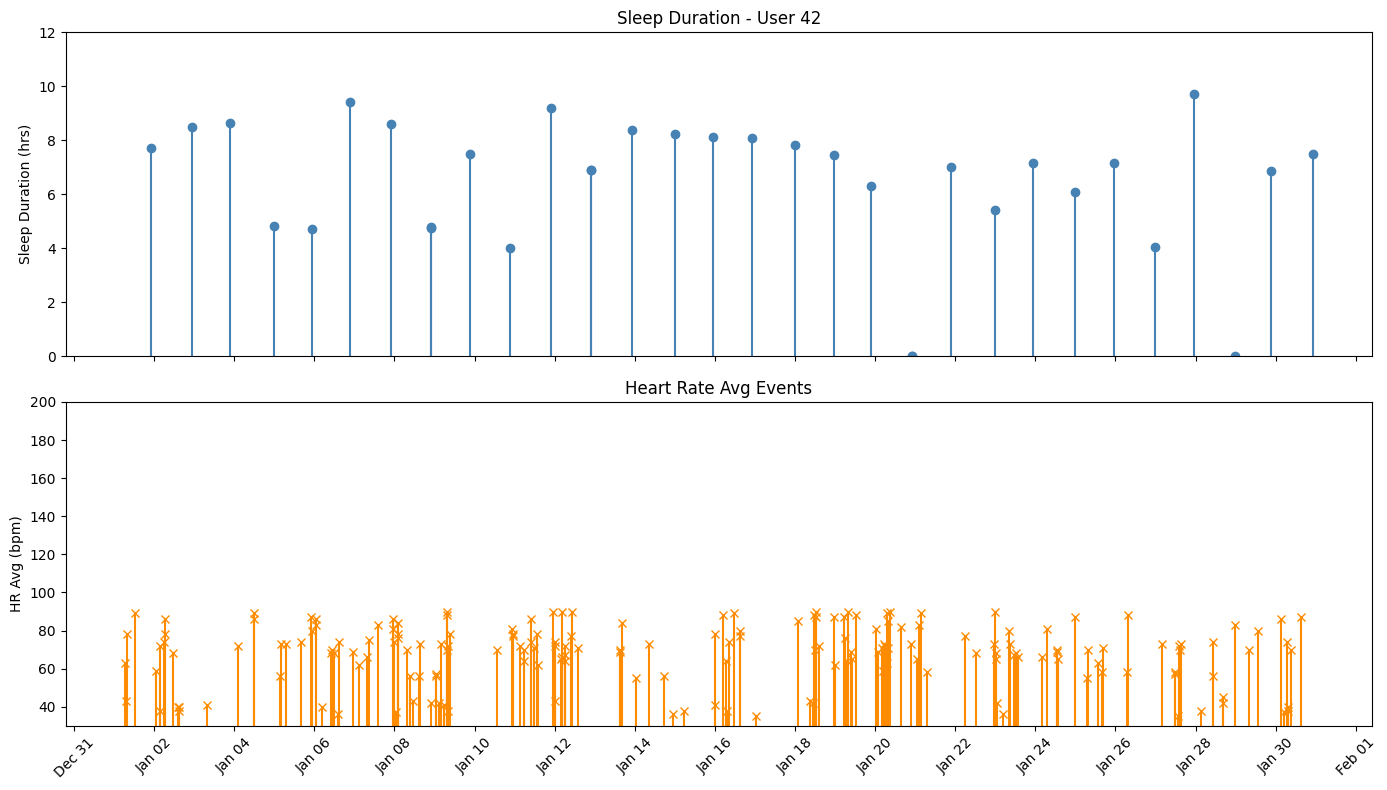

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

user_id = 42
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Lollipop para sueño
ax1.stem(sleep_user['timestamp'], sleep_user['sleep_total_hrs'],
         linefmt='steelblue', markerfmt='o', basefmt=" ")
ax1.set_ylabel('Sleep Duration (hrs)')
ax1.set_ylim(0, 12)
ax1.set_title(f"Sleep Duration - User {user_id}")

# Lollipop para HR
ax2.stem(fc_user['timestamp'], fc_user['hr_avg'],
         linefmt='darkorange', markerfmt='x', basefmt=" ")
ax2.set_ylabel('HR Avg (bpm)')
ax2.set_ylim(30, 200)
ax2.set_title("Heart Rate Avg Events")

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


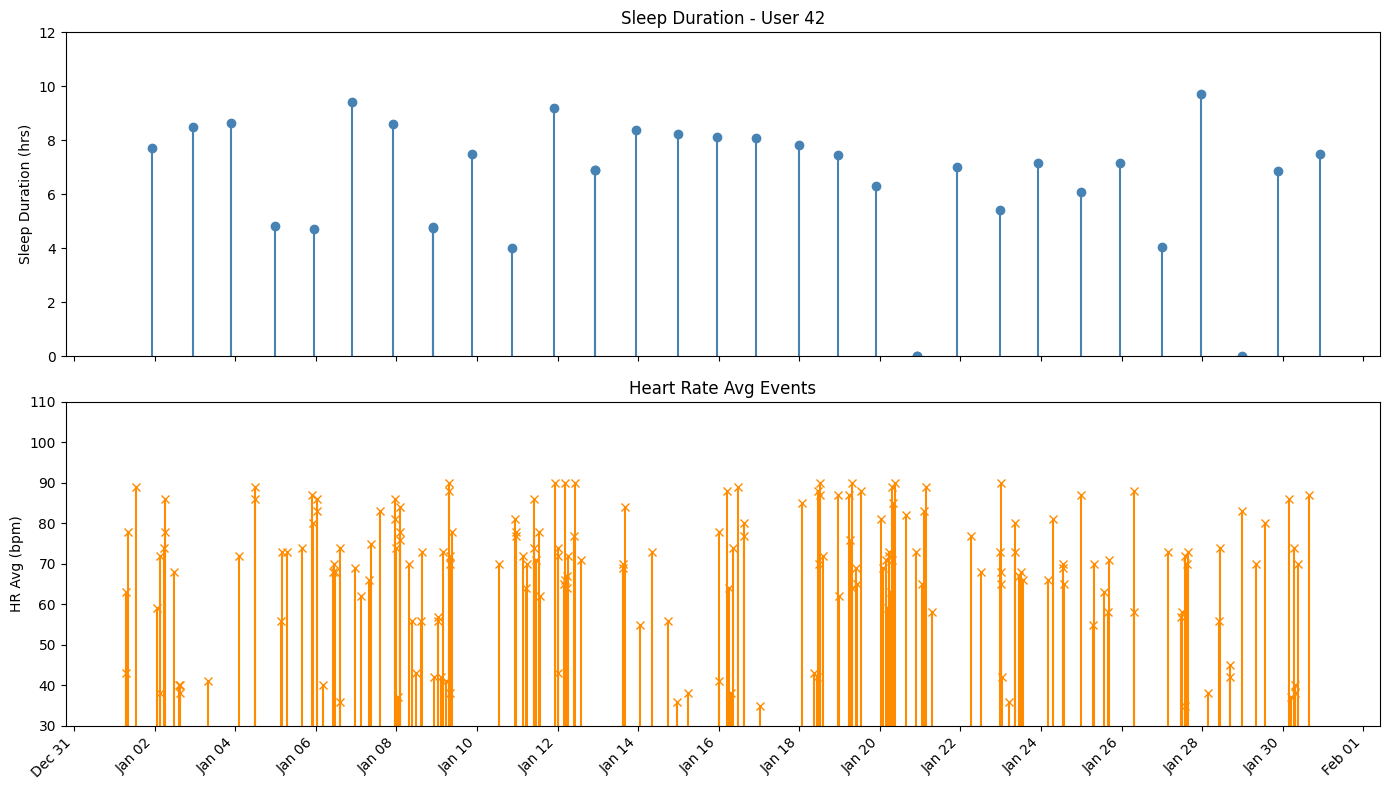

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

user_id = 42
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]
sleep_user['sleep_total_hrs'] = sleep_user[['light', 'rem', 'deep', 'fall_asleep', 'awake']].sum(axis=1) / 3600

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Lollipop para sueño
ax1.stem(sleep_user['timestamp'], sleep_user['sleep_total_hrs'],
         linefmt='steelblue', markerfmt='o', basefmt=" ")
ax1.set_ylabel('Sleep Duration (hrs)')
ax1.set_ylim(0, 12)
ax1.set_title(f"Sleep Duration - User {user_id}")

# Mejor formato de fechas en eje x
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Lollipop para HR
ax2.stem(fc_user['timestamp'], fc_user['hr_avg'],
         linefmt='darkorange', markerfmt='x', basefmt=" ")
ax2.set_ylabel('HR Avg (bpm)')

# Escala ajustada: máximo de los datos + un margen
max_hr = fc_user['hr_avg'].max()
ax2.set_ylim(30, max(110, max_hr + 10))
ax2.set_title("Heart Rate Avg Events")

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


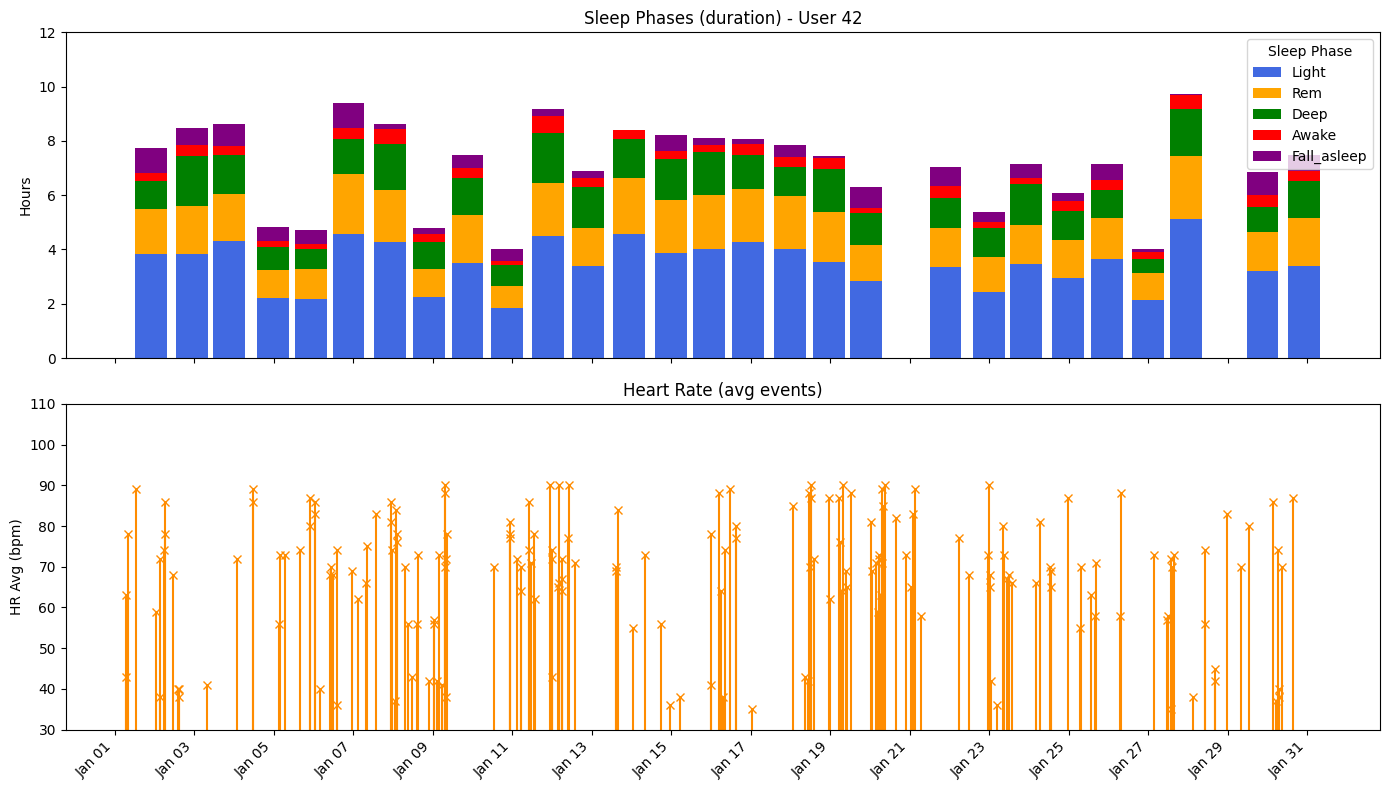

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

user_id = 42
sleep_user = df_sleep[df_sleep['user_id'] == user_id].copy()
fc_user = df_fc[df_fc['user_id'] == user_id].copy()
sleep_user['timestamp'] = pd.to_datetime(sleep_user['timestamp'])
fc_user['timestamp'] = pd.to_datetime(fc_user['timestamp'])
start_date = sleep_user['timestamp'].min().normalize()
end_date = start_date + pd.Timedelta(days=30)
sleep_user = sleep_user[(sleep_user['timestamp'] >= start_date) & (sleep_user['timestamp'] <= end_date)]
fc_user = fc_user[(fc_user['timestamp'] >= start_date) & (fc_user['timestamp'] <= end_date)]

# Convertir de segundos a horas para cada fase
phases = ['light', 'rem', 'deep', 'awake', 'fall_asleep']
for phase in phases:
    sleep_user[phase + '_hrs'] = sleep_user[phase] / 3600

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Colores para cada fase
colors = {
    'light': 'royalblue',
    'rem': 'orange',
    'deep': 'green',
    'awake': 'red',
    'fall_asleep': 'purple'
}

# Preparar datos para barras apiladas
timestamps = sleep_user['timestamp']
bottom = pd.Series([0] * len(sleep_user), index=sleep_user.index)
bars = []
for phase in phases:
    bar = ax1.bar(
        timestamps,
        sleep_user[phase + '_hrs'],
        bottom=bottom,
        label=phase.capitalize(),
        color=colors[phase],
        width=0.8
    )
    bottom += sleep_user[phase + '_hrs']
    bars.append(bar)

ax1.set_ylabel('Hours')
ax1.set_ylim(0, 12)
ax1.set_title(f"Sleep Phases (duration) - User {user_id}")

# Mejor formato de fechas en eje x
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

ax1.legend(title="Sleep Phase")

# Gráfica de HR ajustada
ax2.stem(fc_user['timestamp'], fc_user['hr_avg'],
         linefmt='darkorange', markerfmt='x', basefmt=" ")
ax2.set_ylabel('HR Avg (bpm)')

max_hr = fc_user['hr_avg'].max()
ax2.set_ylim(30, max(110, max_hr + 10))
ax2.set_title("Heart Rate (avg events)")

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
